# Movement To Imagery Transfer With EEGNet

This notebook tests whether an `EEGNet` model trained on actual left/right fist movement can transfer to left/right fist motor imagery.

It follows the reduced-channel configuration used in `benchmarks_best_reduced.ipynb`:

- channels: `sensorimotor_17`
- model: `EEGNet`
- band-pass: `8 to 30 Hz`
- crop window: `0.5 to 2.5 s`
- sampling rate: `160 Hz`

Experiments:

- imagery-only baseline: train on imagery, test on imagery
- movement-to-imagery transfer: train on movement, test on imagery
- movement pretrain + imagery fine-tune: pretrain on movement, fine-tune on imagery, test on imagery


In [1]:
import random
import time
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from braindecode.models import EEGNet
from mne import Epochs, pick_types
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, TensorDataset


warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 7
DATA_ROOT = Path("/NAS/aniruddham/mne/data")
MOVEMENT_RUNS = [3, 7, 11]
IMAGERY_RUNS = [4, 8, 12]
RESAMPLE_SFREQ = 160.0
FILTER_BAND = (8.0, 30.0)
EPOCH_WINDOW = (0.0, 4.0)
CROP_WINDOW = (0.5, 2.5)
TEST_SIZE = 0.2
VAL_SIZE = 0.2
MAX_SUBJECTS = None
BATCH_SIZE = 64
PRETRAIN_EPOCHS = 12
FINETUNE_EPOCHS = 8
BASELINE_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
REDUCED_CHANNELS = [
    "FC5",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",
    "FC6",
    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",
    "CP3",
    "CPz",
    "CP4",
]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MONTAGE = make_standard_montage("standard_1005")

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

print(f"Using device: {DEVICE}")


Using device: cuda


In [2]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def infer_available_subjects(data_root: Path = DATA_ROOT) -> list[int]:
    return sorted(
        int(path.name[1:])
        for path in data_root.glob("S[0-9][0-9][0-9]")
        if path.is_dir()
    )


def local_run_paths(
    subject: int, runs: list[int], data_root: Path = DATA_ROOT
) -> list[Path]:
    subject_name = f"S{subject:03d}"
    return [data_root / subject_name / f"{subject_name}R{run:02d}.edf" for run in runs]


def load_subject_raw(subject: int, runs: list[int]) -> mne.io.BaseRaw:
    paths = local_run_paths(subject, runs)
    if not all(path.exists() for path in paths):
        missing = [path.name for path in paths if not path.exists()]
        raise FileNotFoundError(
            f"Missing EDF files for subject {subject:03d}: {missing}"
        )

    raw = concatenate_raws(
        [read_raw_edf(path, preload=True, verbose="ERROR") for path in paths]
    )
    eegbci.standardize(raw)
    raw.pick("eeg")
    raw.set_montage(MONTAGE, match_case=False, on_missing="warn")
    raw.annotations.rename({"T1": "left_hand", "T2": "right_hand"})
    raw.set_eeg_reference("average", projection=False, verbose="ERROR")
    raw.resample(RESAMPLE_SFREQ, verbose="ERROR")
    raw.filter(
        *FILTER_BAND, fir_design="firwin", skip_by_annotation="edge", verbose="ERROR"
    )
    return raw


def epoch_subject(raw: mne.io.BaseRaw) -> tuple[np.ndarray, np.ndarray, Epochs]:
    events, event_map = mne.events_from_annotations(raw, verbose="ERROR")
    epochs = Epochs(
        raw,
        events,
        event_id={
            "left_hand": event_map["left_hand"],
            "right_hand": event_map["right_hand"],
        },
        tmin=EPOCH_WINDOW[0],
        tmax=EPOCH_WINDOW[1],
        proj=False,
        picks=pick_types(
            raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads"
        ),
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose="ERROR",
    ).crop(*CROP_WINDOW)

    if len(epochs.times) % 2 != 0:
        epochs.crop(tmin=epochs.tmin, tmax=epochs.times[-2])

    X = epochs.get_data(copy=False).astype(np.float32)
    y = (epochs.events[:, -1] == event_map["right_hand"]).astype(np.int64)
    return X, y, epochs


def build_dataset(runs: list[int]) -> dict:
    subjects = infer_available_subjects()
    if MAX_SUBJECTS is not None:
        subjects = subjects[:MAX_SUBJECTS]

    X_parts = []
    y_parts = []
    groups = []
    reduced_picks = None
    reduced_channel_names = None
    reduced_chs_info = None
    example_epochs = None
    kept_subjects = []

    for subject in subjects:
        raw = load_subject_raw(subject, runs)
        X, y, epochs = epoch_subject(raw)
        if reduced_picks is None:
            name_to_idx = {name: idx for idx, name in enumerate(epochs.ch_names)}
            reduced_picks = [
                name_to_idx[ch] for ch in REDUCED_CHANNELS if ch in name_to_idx
            ]
            reduced_channel_names = [epochs.ch_names[idx] for idx in reduced_picks]
            reduced_chs_info = [
                deepcopy(epochs.info["chs"][idx]) for idx in reduced_picks
            ]
            example_epochs = epochs.copy()

        X = X[:, reduced_picks, :]
        mean = X.mean(axis=2, keepdims=True)
        std = X.std(axis=2, keepdims=True) + 1e-6
        X = (X - mean) / std

        X_parts.append(X)
        y_parts.append(y)
        groups.append(np.full(len(y), subject))
        kept_subjects.append(subject)

    return {
        "X": np.concatenate(X_parts, axis=0),
        "y": np.concatenate(y_parts, axis=0),
        "groups": np.concatenate(groups, axis=0),
        "subjects": kept_subjects,
        "channel_names": reduced_channel_names,
        "chs_info": reduced_chs_info,
        "sfreq": RESAMPLE_SFREQ,
        "example_epochs": example_epochs,
        "reduced_picks": reduced_picks,
    }


def make_group_split(groups: np.ndarray, seed: int = SEED) -> dict:
    index = np.arange(len(groups))
    outer = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    train_val_idx, test_idx = next(outer.split(index, groups=groups))
    inner = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=seed + 1)
    inner_train_rel, inner_val_rel = next(
        inner.split(np.arange(len(train_val_idx)), groups=groups[train_val_idx])
    )
    return {
        "train": train_val_idx[inner_train_rel],
        "val": train_val_idx[inner_val_rel],
        "test": test_idx,
    }


set_seed()
movement_ds = build_dataset(MOVEMENT_RUNS)
imagery_ds = build_dataset(IMAGERY_RUNS)
imagery_split = make_group_split(imagery_ds["groups"])

summary = pd.DataFrame(
    {
        "dataset": ["movement", "imagery"],
        "subjects": [len(movement_ds["subjects"]), len(imagery_ds["subjects"])],
        "epochs": [len(movement_ds["y"]), len(imagery_ds["y"])],
        "left_trials": [
            int((movement_ds["y"] == 0).sum()),
            int((imagery_ds["y"] == 0).sum()),
        ],
        "right_trials": [
            int((movement_ds["y"] == 1).sum()),
            int((imagery_ds["y"] == 1).sum()),
        ],
        "channels": [
            len(movement_ds["channel_names"]),
            len(imagery_ds["channel_names"]),
        ],
        "samples_per_epoch": [movement_ds["X"].shape[-1], imagery_ds["X"].shape[-1]],
    }
)
display(summary)
print("Reduced channels:", ", ".join(imagery_ds["channel_names"]))


,dataset,subjects,epochs,left_trials,right_trials,channels,samples_per_epoch
0,movement,109,4897,2452,2445,17,320
1,imagery,109,4898,2470,2428,17,320


Reduced channels: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, CP3, CPz, CP4


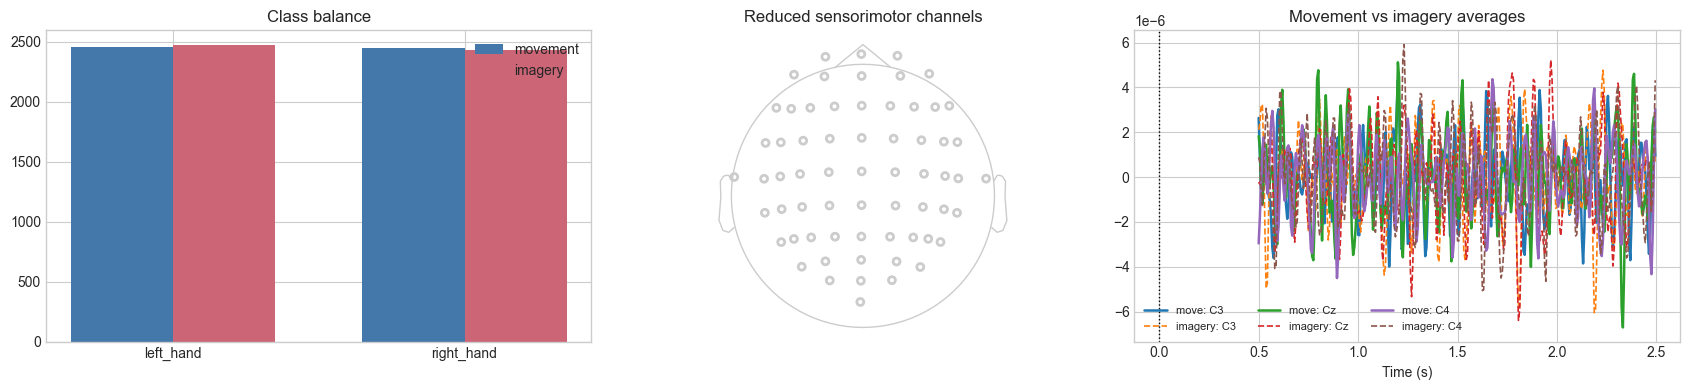

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

movement_counts = (
    pd.Series(movement_ds["y"])
    .map({0: "left_hand", 1: "right_hand"})
    .value_counts()
    .sort_index()
)
imagery_counts = (
    pd.Series(imagery_ds["y"])
    .map({0: "left_hand", 1: "right_hand"})
    .value_counts()
    .sort_index()
)
x = np.arange(2)
width = 0.35
axes[0].bar(
    x - width / 2,
    movement_counts.values,
    width=width,
    label="movement",
    color="#4477AA",
)
axes[0].bar(
    x + width / 2, imagery_counts.values, width=width, label="imagery", color="#CC6677"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(movement_counts.index)
axes[0].set_title("Class balance")
axes[0].legend()

mne.viz.plot_sensors(
    imagery_ds["example_epochs"].info,
    axes=axes[1],
    show=False,
    kind="topomap",
    ch_groups=[imagery_ds["reduced_picks"]],
)
axes[1].set_title("Reduced sensorimotor channels")

motor_channels = [
    ch for ch in ["C3", "Cz", "C4"] if ch in imagery_ds["example_epochs"].ch_names
]
movement_evoked = (
    movement_ds["example_epochs"]["left_hand"].average().pick(motor_channels)
)
imagery_evoked = (
    imagery_ds["example_epochs"]["left_hand"].average().pick(motor_channels)
)
for ch_name in motor_channels:
    idx = movement_evoked.ch_names.index(ch_name)
    axes[2].plot(
        movement_evoked.times,
        movement_evoked.data[idx],
        label=f"move: {ch_name}",
        linewidth=1.8,
    )
    axes[2].plot(
        imagery_evoked.times,
        imagery_evoked.data[idx],
        label=f"imagery: {ch_name}",
        linestyle="--",
        linewidth=1.2,
    )
axes[2].axvline(0.0, color="black", linestyle=":", linewidth=1)
axes[2].set_title("Movement vs imagery averages")
axes[2].set_xlabel("Time (s)")
axes[2].legend(ncol=3, fontsize=8)

plt.tight_layout()
plt.show()


In [4]:
def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    return DataLoader(
        TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        drop_last=False,
    )


def unpack_logits(logits):
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    while logits.ndim > 2 and logits.shape[-1] == 1:
        logits = logits.squeeze(-1)
    if logits.ndim > 2:
        logits = logits.mean(dim=tuple(range(2, logits.ndim)))
    return logits


@torch.no_grad()
def collect_predictions(
    model: nn.Module, loader: DataLoader
) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    pred_labels = []
    pred_probs = []
    for batch_X, _ in loader:
        batch_X = batch_X.to(DEVICE)
        logits = unpack_logits(model(batch_X))
        probs = torch.softmax(logits, dim=1)[:, 1]
        pred_probs.append(probs.cpu().numpy())
        pred_labels.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(pred_labels), np.concatenate(pred_probs)


def evaluate_loss_accuracy(
    model: nn.Module, loader: DataLoader, criterion: nn.Module
) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for batch_X, batch_y in loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        logits = unpack_logits(model(batch_X))
        loss = criterion(logits, batch_y)
        total_loss += loss.item() * len(batch_y)
        total_correct += (logits.argmax(dim=1) == batch_y).sum().item()
        total_count += len(batch_y)
    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


def build_model() -> nn.Module:
    return EEGNet(
        n_chans=imagery_ds["X"].shape[1],
        n_times=imagery_ds["X"].shape[2],
        n_outputs=2,
        sfreq=imagery_ds["sfreq"],
        chs_info=imagery_ds["chs_info"],
    ).to(DEVICE)


def train_phase(
    model, train_loader, val_loader, y_val, max_epochs, phase_name, lr=LEARNING_RATE
):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    history = []
    best_state = None
    best_val_bal = -np.inf
    best_epoch = 0
    patience_counter = 0
    start = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = unpack_logits(model(batch_X))
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate_loss_accuracy(model, train_loader, criterion)
        val_loss, val_acc = evaluate_loss_accuracy(model, val_loader, criterion)
        val_pred, _ = collect_predictions(model, val_loader)
        val_bal = balanced_accuracy_score(y_val, val_pred)

        history.append(
            {
                "phase": phase_name,
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_accuracy": train_acc,
                "val_accuracy": val_acc,
                "val_balanced_accuracy": val_bal,
            }
        )

        if val_bal > best_val_bal + 1e-4:
            best_val_bal = val_bal
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                break

    duration = time.perf_counter() - start
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch, duration


def summarize_test(model, X_test, y_test, groups_test, label):
    test_loader = make_loader(X_test, y_test, shuffle=False)
    pred, prob = collect_predictions(model, test_loader)
    return {
        "experiment": label,
        "test_accuracy": float((pred == y_test).mean()),
        "test_balanced_accuracy": float(balanced_accuracy_score(y_test, pred)),
        "test_auc": float(roc_auc_score(y_test, prob)),
        "pred": pred,
        "prob": prob,
        "groups": groups_test,
    }


imagery_train_idx = imagery_split["train"]
imagery_val_idx = imagery_split["val"]
imagery_test_idx = imagery_split["test"]

X_i_train, y_i_train = (
    imagery_ds["X"][imagery_train_idx],
    imagery_ds["y"][imagery_train_idx],
)
X_i_val, y_i_val = imagery_ds["X"][imagery_val_idx], imagery_ds["y"][imagery_val_idx]
X_i_test, y_i_test = (
    imagery_ds["X"][imagery_test_idx],
    imagery_ds["y"][imagery_test_idx],
)
g_i_test = imagery_ds["groups"][imagery_test_idx]

movement_split = make_group_split(movement_ds["groups"])
X_m_train, y_m_train = (
    movement_ds["X"][movement_split["train"]],
    movement_ds["y"][movement_split["train"]],
)
X_m_val, y_m_val = (
    movement_ds["X"][movement_split["val"]],
    movement_ds["y"][movement_split["val"]],
)

baseline_model = build_model()
baseline_model, baseline_hist, baseline_best_epoch, baseline_time = train_phase(
    baseline_model,
    make_loader(X_i_train, y_i_train, shuffle=True),
    make_loader(X_i_val, y_i_val, shuffle=False),
    y_i_val,
    BASELINE_EPOCHS,
    phase_name="imagery_only",
)
baseline_result = summarize_test(
    baseline_model, X_i_test, y_i_test, g_i_test, "imagery_only"
)
baseline_result["best_epoch"] = baseline_best_epoch
baseline_result["training_time_s"] = baseline_time

transfer_model = build_model()
transfer_model, transfer_hist, transfer_best_epoch, transfer_time = train_phase(
    transfer_model,
    make_loader(X_m_train, y_m_train, shuffle=True),
    make_loader(X_m_val, y_m_val, shuffle=False),
    y_m_val,
    PRETRAIN_EPOCHS,
    phase_name="movement_pretrain",
)
transfer_result = summarize_test(
    transfer_model, X_i_test, y_i_test, g_i_test, "movement_to_imagery"
)
transfer_result["best_epoch"] = transfer_best_epoch
transfer_result["training_time_s"] = transfer_time

finetune_model = build_model()
finetune_model, pre_hist, pre_best_epoch, pre_time = train_phase(
    finetune_model,
    make_loader(X_m_train, y_m_train, shuffle=True),
    make_loader(X_m_val, y_m_val, shuffle=False),
    y_m_val,
    PRETRAIN_EPOCHS,
    phase_name="movement_pretrain",
)
finetune_model, ft_hist, ft_best_epoch, ft_time = train_phase(
    finetune_model,
    make_loader(X_i_train, y_i_train, shuffle=True),
    make_loader(X_i_val, y_i_val, shuffle=False),
    y_i_val,
    FINETUNE_EPOCHS,
    phase_name="imagery_finetune",
    lr=LEARNING_RATE * 0.5,
)
finetune_result = summarize_test(
    finetune_model,
    X_i_test,
    y_i_test,
    g_i_test,
    "movement_pretrain_plus_imagery_finetune",
)
finetune_result["best_epoch"] = ft_best_epoch
finetune_result["training_time_s"] = pre_time + ft_time

history_df = pd.concat(
    [baseline_hist, transfer_hist, pre_hist, ft_hist], ignore_index=True
)
results_df = pd.DataFrame(
    [
        {
            k: v
            for k, v in baseline_result.items()
            if k not in {"pred", "prob", "groups"}
        },
        {
            k: v
            for k, v in transfer_result.items()
            if k not in {"pred", "prob", "groups"}
        },
        {
            k: v
            for k, v in finetune_result.items()
            if k not in {"pred", "prob", "groups"}
        },
    ]
)
display(results_df.sort_values("test_balanced_accuracy", ascending=False))


,experiment,test_accuracy,test_balanced_accuracy,test_auc,best_epoch,training_time_s
0,imagery_only,0.587462,0.586444,0.629939,10,6.444861
2,movement_pretrain_plus_imagery_finetune,0.570273,0.569714,0.619051,8,10.180713
1,movement_to_imagery,0.486350,0.490290,0.483877,3,3.316827


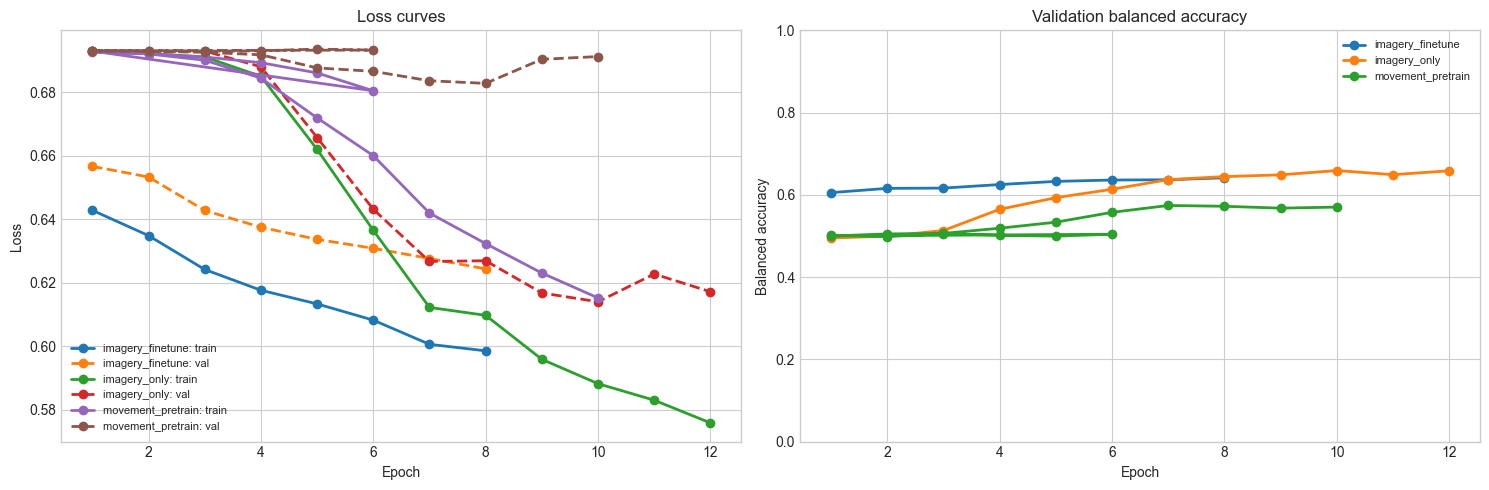

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for experiment, df in history_df.groupby("phase"):
    axes[0].plot(
        df["epoch"],
        df["train_loss"],
        marker="o",
        linewidth=2,
        label=f"{experiment}: train",
    )
    axes[0].plot(
        df["epoch"],
        df["val_loss"],
        marker="o",
        linewidth=2,
        linestyle="--",
        label=f"{experiment}: val",
    )
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

for experiment, df in history_df.groupby("phase"):
    axes[1].plot(
        df["epoch"],
        df["val_balanced_accuracy"],
        marker="o",
        linewidth=2,
        label=experiment,
    )
axes[1].set_title("Validation balanced accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Balanced accuracy")
axes[1].set_ylim(0.0, 1.0)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


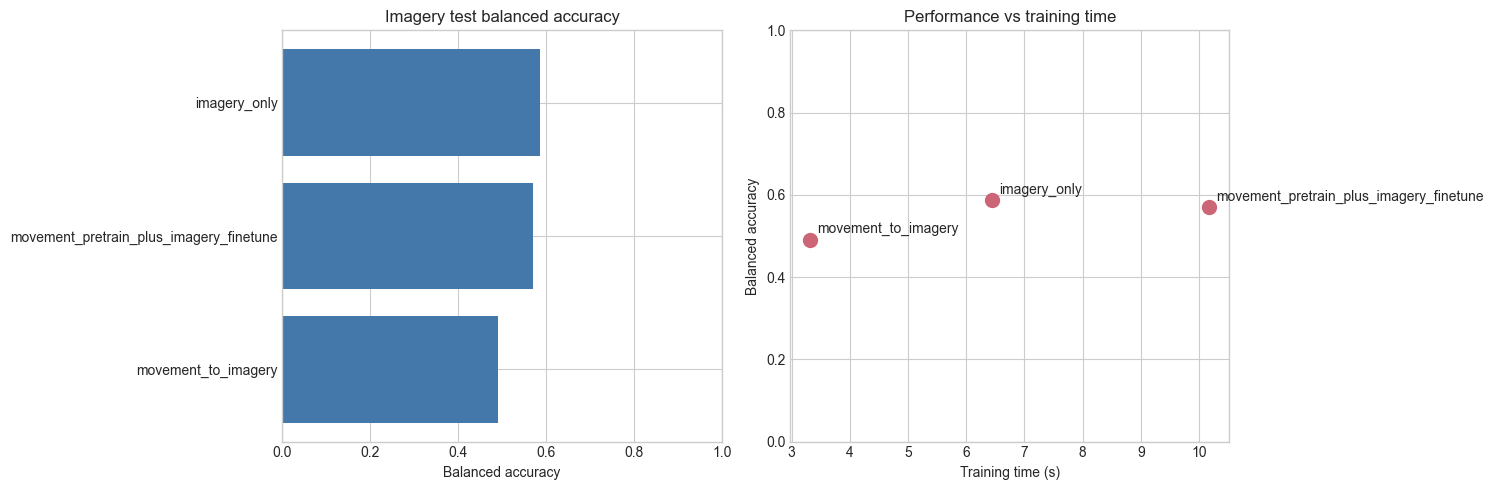

In [6]:
comparison_plot = results_df.sort_values("test_balanced_accuracy", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(
    comparison_plot["experiment"],
    comparison_plot["test_balanced_accuracy"],
    color="#4477AA",
)
axes[0].set_title("Imagery test balanced accuracy")
axes[0].set_xlabel("Balanced accuracy")
axes[0].set_xlim(0.0, 1.0)

axes[1].scatter(
    comparison_plot["training_time_s"],
    comparison_plot["test_balanced_accuracy"],
    s=100,
    color="#CC6677",
)
for _, row in comparison_plot.iterrows():
    axes[1].annotate(
        row["experiment"],
        (row["training_time_s"], row["test_balanced_accuracy"]),
        xytext=(5, 5),
        textcoords="offset points",
    )
axes[1].set_title("Performance vs training time")
axes[1].set_xlabel("Training time (s)")
axes[1].set_ylabel("Balanced accuracy")
axes[1].set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()


Best experiment: imagery_only
              precision    recall  f1-score   support

   left_hand       0.58      0.68      0.62       500
  right_hand       0.60      0.49      0.54       489

    accuracy                           0.59       989
   macro avg       0.59      0.59      0.58       989
weighted avg       0.59      0.59      0.58       989



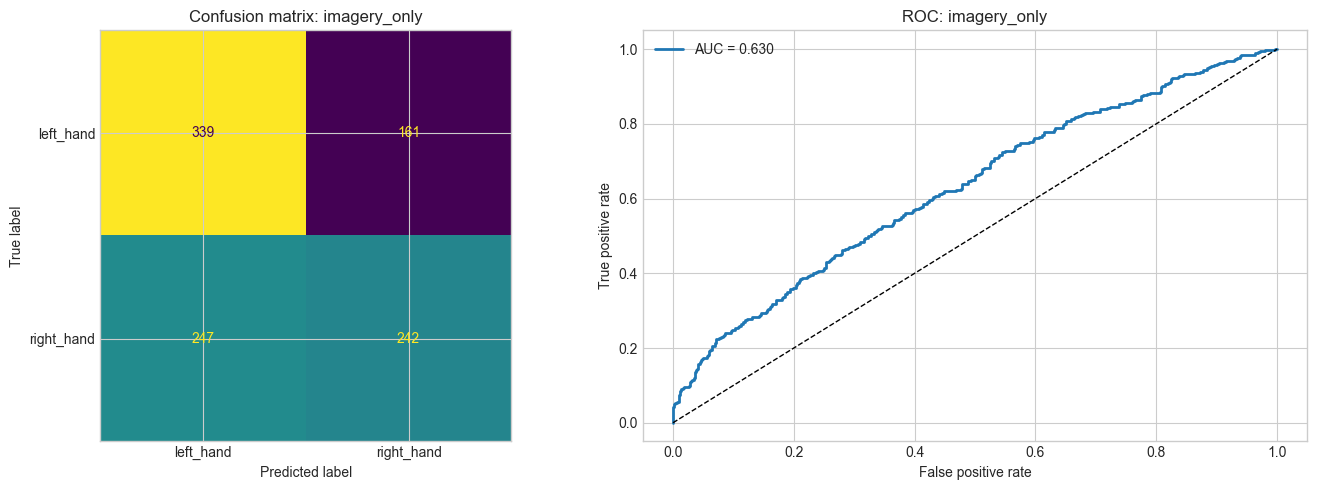

In [7]:
best_experiment_name = results_df.sort_values(
    "test_balanced_accuracy", ascending=False
)["experiment"].iloc[0]
experiment_map = {
    "imagery_only": baseline_result,
    "movement_to_imagery": transfer_result,
    "movement_pretrain_plus_imagery_finetune": finetune_result,
}
best_result = experiment_map[best_experiment_name]

print(f"Best experiment: {best_experiment_name}")
print(
    classification_report(
        y_i_test, best_result["pred"], target_names=["left_hand", "right_hand"]
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_i_test, best_result["pred"])
ConfusionMatrixDisplay(cm, display_labels=["left_hand", "right_hand"]).plot(
    ax=axes[0], colorbar=False
)
axes[0].set_title(f"Confusion matrix: {best_experiment_name}")

fpr, tpr, _ = roc_curve(y_i_test, best_result["prob"])
auc = roc_auc_score(y_i_test, best_result["prob"])
axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
axes[1].set_title(f"ROC: {best_experiment_name}")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend()

plt.tight_layout()
plt.show()


,subject,n_trials,accuracy,balanced_accuracy,mean_pred_prob_right
16,94,45,0.822222,0.819170,0.554288
6,38,45,0.688889,0.686759,0.446035
2,14,45,0.666667,0.666008,0.507988
9,50,45,0.666667,0.662055,0.445889
20,107,45,0.644444,0.648810,0.492343
3,21,45,0.622222,0.645833,0.629497
15,86,45,0.644444,0.645257,0.479311
4,23,45,0.644444,0.643281,0.495339
8,47,45,0.622222,0.619048,0.486586
10,51,45,0.622222,0.610119,0.459541


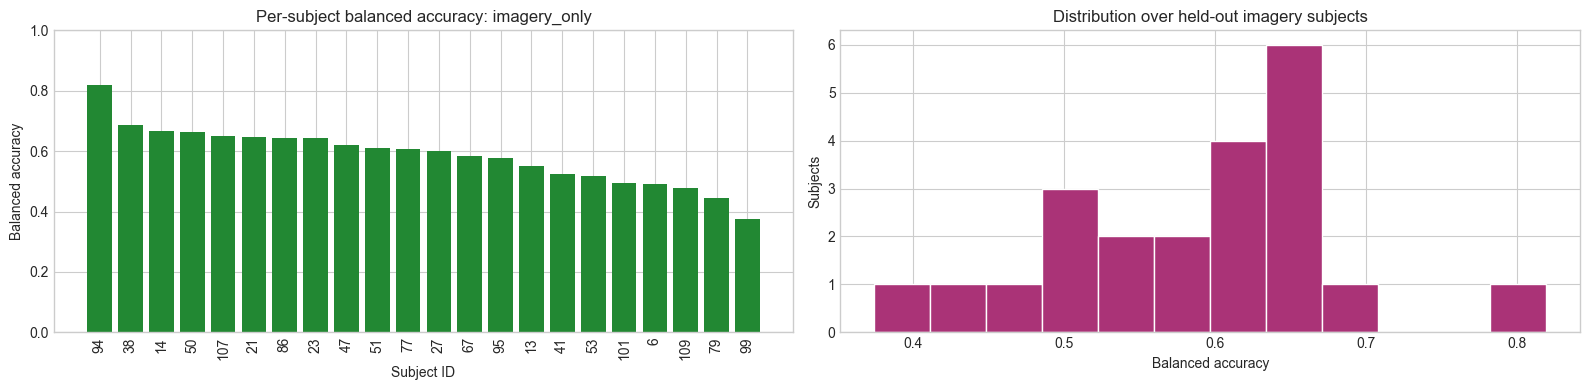

In [8]:
per_subject_rows = []
groups_test = best_result["groups"]
for subject in np.unique(groups_test):
    mask = groups_test == subject
    y_subject = y_i_test[mask]
    pred_subject = best_result["pred"][mask]
    prob_subject = best_result["prob"][mask]
    per_subject_rows.append(
        {
            "subject": int(subject),
            "n_trials": int(mask.sum()),
            "accuracy": float((pred_subject == y_subject).mean()),
            "balanced_accuracy": float(
                balanced_accuracy_score(y_subject, pred_subject)
            ),
            "mean_pred_prob_right": float(prob_subject.mean()),
        }
    )

per_subject_df = pd.DataFrame(per_subject_rows).sort_values(
    "balanced_accuracy", ascending=False
)
display(per_subject_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].bar(
    per_subject_df["subject"].astype(str),
    per_subject_df["balanced_accuracy"],
    color="#228833",
)
axes[0].set_title(f"Per-subject balanced accuracy: {best_experiment_name}")
axes[0].set_xlabel("Subject ID")
axes[0].set_ylabel("Balanced accuracy")
axes[0].set_ylim(0.0, 1.0)
axes[0].tick_params(axis="x", rotation=90)

axes[1].hist(
    per_subject_df["balanced_accuracy"], bins=12, color="#AA3377", edgecolor="white"
)
axes[1].set_title("Distribution over held-out imagery subjects")
axes[1].set_xlabel("Balanced accuracy")
axes[1].set_ylabel("Subjects")

plt.tight_layout()
plt.show()
